# Project 1: Data Analysis Project

## Table of contents <a id='toc0_'></a>
- [Question 1: Inequality in Denmark](#toc1_)
  - [Question 1.1: The Gini Coefficient and the Top 10 Percent Share](#toc1_1_)
  - [Question 1.2: Prediction](#toc1_2_)
  - [Question 1.3: Municipalities](#toc1_3_)
  - [Question 1.4: Extension](#toc1_4_)
- [Question 2: Simulating the Income Distribution](#toc2_)
  - [Question 2.1: The Model](#toc2_1_)
  - [Question 2.2: Simulate the Income Distribution](#toc2_2_)
  - [Question 2.3: Compute the Gini Coefficient](#toc2_3_)
  - [Question 2.4: What Drives Inequality?](#toc2_4_)
  - [Question 2.5: Extension: More Risk](#toc2_5_)

We import the nessesary packages:

In [ ]:
# Import all necessary packages
import numpy as np
import pandas as pd

# APIs
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# functions
import dataproject

## Question 1: Inequality in Denmark <a id='toc1_'></a>

### Question 1.1: The Gini Coefficient and the Top 10 Percent Share <a id='toc1_1_'></a>

We start by getting a overview of the two datasets from Statistic Denmark (DST).

In [ ]:
# Below are some lines of code to explore the datasets. 
# Theses are commented out in the final version of the notebook, 
# but they are used to get a better understanding of the data.

IFOR41 = DstApi('IFOR41') 
IFOR32 = DstApi('IFOR32')

#IFOR41.tablesummary(language='en')
#IFOR32.tablesummary(language='en')

#IFOR41.variable_levels('ULLIG',language='en')
#IFOR41.variable_levels('KOMMUNEDK',language='en')

#IFOR32.variable_levels('DECILGEN',language='en')
#IFOR32.variable_levels('KOMMUNEDK',language='en')



As the Hint in the project describing tells us is this Gini coefficient indicated by `ULLIG = 70`.

The data also consist of a municipality dimension with the 98 municipalities and a `All Denmark = 000`. We load all data about the Gini coefficient from all munipalities from 1987 in the begining since later exercises are exploring the municipality differences

In [ ]:
# Download both datasets and store them in one inequality dataset.
df_IFOR41 = dataproject.load_IFOR41(ULLIG = '70', KOMMUNEDK = '*', varname='gini')
df_IFOR32 = dataproject.load_IFOR32(DECILGEN = '*', KOMMUNEDK = '*', varname='avg_income')

# Merge the two datasets into one dataset by year and municipality where year is the index.
df_ineq = pd.merge(df_IFOR32, df_IFOR41, 
                   on = ['year', 'municipality'], 
                   how = 'inner', # Use inner since both datasets should have the same years and municipalities.
                   validate = '1:1') # Passed: No merge error.

df_ineq = df_ineq.set_index(['year']).sort_index().sort_values(by=['municipality'])

# Compute the Denmark subset of the dataset for municipalities.
denmark = df_ineq[df_ineq['municipality'] == 'All Denmark']

We start my plotting the Gini coefficient for Denmark from 1987-2024.

In [ ]:
# Makes a Gini and top 10 pct. share plots for Denmark (municipalities = All Denmark) between 1987 and 2024.

fig, ax = plt.subplots(figsize=(12,6)) # Gini
fig, bx = plt.subplots(figsize=(12,6)) # Top 10 pct. share

# Gini coefficient plot
denmark.plot(y = 'gini', 
             ax = ax, 
             color = colors[0], 
             legend = False)

ax.set_xticks(denmark.index.unique()) # Year is set as the index.
ax.set_xticklabels(denmark.index.unique(), rotation=45)

ax.set_title('Gini coefficient in Denmark (1987-2024)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Gini coefficient', fontsize=14)

# Top 10 pct. share plot
denmark.plot(y = 'avg_income_top10_share', 
             ax = bx, 
             color = colors[0], 
                                                       legend = False)

bx.set_xticks(denmark.index.unique()) # Year is set as the index.
bx.set_xticklabels(denmark.index.unique(), rotation=45)

bx.set_title('Top 10% share in Denmark (1987-2024)', fontsize=16)
bx.set_xlabel('Year', fontsize=14)
bx.set_ylabel('Top 10% share', fontsize=14)

fig.tight_layout()

The Gini coefficient for Denmark rises over the whole period, indicating a gradual increase in income inequality from 1987 to 2024. At the same time, the share of total income going to the richest 10 percent follows the same pattern, rising alongside the Gini and showing temporary declines during economic downturns such as the dot-com bubble, the financial crisis and the COVID-19 pandemic. This suggests that higher inequality is strongly linked to the top income share, and to check this relationship we compute the correlation between the two series over time.

In [ ]:
# Compute the correlation between Gini and top 10% share for Denmark between 1987 and 2024.

corr_gini_top10 = denmark['gini'].corr(denmark['avg_income_top10_share'])
print(f'The correlation between Gini and top 10% share in Denmark (1987-2024) is: {corr_gini_top10:.4f}')

Thus, the Gini coeficient and top 10% share for Denmark almost perfectly correlates between 1987 and 2024.

### Question 1.2: Prediction <a id='toc1_2_'></a>

To predict inequality in Denmark in 2030 and 2040, we compute the linear and quadratic trend to the Gini coefficient. We do this by first defining the polynomial trend of degree p, then solve the minimization problem to find the value of beta that best fits our data and compare it to np.plyfit

In [ ]:
#define the polynomial function
def S(beta, t, y, p):
    # beta=[beta_0, beta_1,..., beta_p]
    pred=sum(beta[k]*t**k for k in range(p+1)) #calculating the inner sum
    return np.sum((y-pred)**2)

#import packages we need
from scipy import optimize

#compute time, so that it is years since 1987 and define the gini variable as a vector:
time= (df_ineq.index.values - df_ineq.index.min())
gini = df_ineq['gini'].values

# 1. Now, we find the values of beta, beta_hat1 and beta_hat2 that best fit the data-points

degrees= [1,2]
results={}

print("when using optimize.minimize, the results are:")
for p in degrees:
    initial_guess = np.zeros(p+1) #make the vector
    initial_guess[0] = gini.mean() #and guess it is the mean 
    res = optimize.minimize(S, initial_guess, args=(time, gini, p), method='Nelder-Mead')
    results[p] = res

    
    print(f"for p = {p}")
    print(f"  success: {res.success}")
    print(f"  coefficients (betahat_0 ... betahat_{p}): {res.x}")
    print(f"  S(betahat) at optimum: {res.fun}")
    print()

# 2. We now check the results against np.polyfit
# for linear, p=1
poly_1=np.polyfit(time, gini, 1)
poly_2=np.polyfit(time, gini, 2)

print("when using np.polyfit, the results are:")
print(f'for p=1, betahat={poly_1}')
print(f'for p=2, betahat={poly_2}')


So we find that both methods find the same values of $\hat{\beta}$. We find that the linear trend finds that in the first year, 1987, gini coefficient is around 20 and rises slightly every year, which is also what we found in the figure in 1.1.
Furthermore, we find that the fit of the linear and quadratic trend are almost the same, meaning there is little to be gained by using the quadratic polynomial trend. 

We now use the estimates to predict what the gini coefficient is in 2030 and 2040, by using the function predict

In [ ]:
# 3. We predict the Gini coefficient in 2030 and 2040, and plot the result

def predict(beta, t, p):
    return sum(beta[k]*t**k for k in range(p+1))

#define the two predictions we want
t_2030= 2030-1987
t_2040=2040-1987

for p in degrees:
    beta=results[p].x
    pred_2030=predict(beta, t_2030, p)
    pred_2040=predict(beta, t_2040, p)

    print(f"p={p}")
    print(f"  predicted Gini coefficient in 2030: {pred_2030:.2f}")
    print(f"  predicted Gini coefficient in 2040: {pred_2040:.2f}")
    print()



# We now plot the predicted values with the historic data, plotted in denmark_plot for gini:
fig, cx = plt.subplots(figsize=(12,6)) # Gini predictions
denmark.plot(y = 'gini', 
             ax = cx, 
             color = colors[0])



#Now add the predictions:
for p in degrees:
    beta = results[p].x
    pred_2030 = predict(beta, t_2030, p)
    pred_2040 = predict(beta, t_2040, p)
    
    cx.scatter([2030, 2040], [pred_2030, pred_2040],
               color=colors[p], marker='o', s=80, 
               label=f'p={p} prediction')

extra_years = list(range(2024, 2041))
cx.set_xticks(denmark.index.unique().tolist() + extra_years)  # add 2030/2040 to ticks
cx.set_xticklabels(cx.get_xticks(), rotation=90)

cx.set_title(' Observed Gini coefficient in Denmark (1987-2024) with predictions for 2030 and 2040', fontsize=16)
cx.set_xlabel('Year', fontsize=14)
cx.set_ylabel('Gini coefficient', fontsize=14)
cx.legend()
fig.tight_layout()


So we find that the quadratic trend predicts a slightly higher Gini coefficient in Denmark in 2030 and 2040 than the linear trend, however the predicitions are very similar, with only decimal differing. Both predict that the gini-coefficient will fall from 2024 to 2030 to 29, and will be around 32 in 2040. The specifictaions does fit the historical data, however based on the trend in the last 15 years, the prediction should perhaps be slightly higher.

We think that the predictions can be used as a good overall guess, but as we commented on in 1.1, the gini coefficient is linked to the general economic situation within the country, as well as political initiatives, and therefore, it may be too simple of a way to predict it.




### Question 1.3: Municipalities <a id='toc1_3_'></a>

<u> *Question 1.3.1: The correlation between the gini coef. and the top 10% share over time* <u>

In [ ]:
# A. Calculating the correlation across all observations for each year
corr_by_year = (
    df_ineq.groupby("year") 
    .apply(lambda x: x["gini"].corr(x["avg_income_top10_share"])) # for each year the observations are saved in a dataset x and for this dataset the corr. is calculated.
    .reset_index(name="correlation")
)

# B. Plotting the correlation across years
plt.plot(corr_by_year["year"], corr_by_year["correlation"])
plt.title("Yearly correlation between x and y")
plt.xlabel("Year")
plt.ylabel("Correlation")
plt.grid(True)
plt.axhline(0.965, color = "black") # Inserting a horizontal line of what the corr. was found to be for all of Denmark.
plt.ticklabel_format(style="plain", axis="y")
plt.show()

The correlation between the Gini coefficient and the top 10 percent share can be seen to fluctuate around 0.965 with no deviations larger 0.02 for the entire period of 1987-2024. Compared to the correlation size calculated for the entire of Denmark (indicated by the horizontal black line), the correlation calculated on municipality-level is very much the same.

<u> *Question 1.3.2: The 10 most and least unequal municipalities* <u>

In [ ]:
# A. Finding the top and bottom 10 gini coefs. in 2024
# i. Saving only observations from latest year (2024)
df_2024 = df_ineq.loc[2024]

# ii. Sorting data by gini coef.
df_2024.sort_values("gini")

# iii. Printing top 10 gini coefs. of 2024
df_2024.nlargest(10, "gini")[["municipality", "gini"]]

# iv. Printing bottom 10 coefs. of 2024
df_2024.nsmallest(10, "gini")[["municipality", "gini"]]

# v. Saving two lists of these and combining them to one list
lowest_10 = df_2024.nsmallest(10, "gini")["municipality"].tolist()
highest_10 = df_2024.nlargest(10, "gini")["municipality"].tolist()
selected_municipalities = lowest_10 + highest_10

# vi. Saving only these municipalities in the dataset containing the gini coefs. across the entire period
df_selected = df_ineq[df_ineq["municipality"].isin(selected_municipalities)]
df_selected["municipality"].unique()



# B. Plotting the selected 20 municipalities' gini coefs. across the entire period
plt.figure(figsize=(14, 10))

# i. Plotting the top 10 municipalities
for municipality in highest_10:
    data = df_selected[df_selected["municipality"] == municipality]
    plt.plot(data.index, data["gini"], linestyle="-", label=municipality)

# ii. Plotting the bottom 10 municipalities in stippled lines
for municipality in lowest_10:
    data = df_selected[df_selected["municipality"] == municipality]
    plt.plot(data.index, data["gini"], linestyle="--", label=municipality)

plt.xlabel("Year")
plt.ylabel("Gini")
plt.title("Development in Gini for top- and bottom 10 municipalities")
plt.legend(bbox_to_anchor=(1.001, 0.8), loc="upper left", fontsize=12)
plt.show()


The figure reveals that both the top and bottom 10 municipalities experience an increase in the Gini in the period of 1987-2024. In the late 1980's the municipalities of Copenhagen, Aarhus, Helsingør, and Vejen were on level with the group of the bottom 10 but have since been on a steeper path towards a higher Gini compared to the group of the 10 lowest Gini's. An outlier of the data is Vejen whose Gini skyrocketed in 2023 which - according to a quick Google-search - was the result of a rich person selling some of their stocks.

<u> *Question 1.3.3: The countries with the largest and smallest changes in Gini* <u>

In [ ]:
# A. Finding the 10 largest and 10 smallest changes in Gini

# i. Transforming the year from an index to a variable as to be able to use it for calculations
df_noindex = df_ineq.reset_index()

# ii. Generating a data frame keeping only observations from 1987 and 2024 
gini_change = (
    df_noindex[df_noindex["year"].isin([1987, 2024])]
    .pivot(index="municipality", columns="year", values="gini")
)

# iii. Generating a variable being the difference from first year (1987) to last year (2024) in Gini for each municipality
gini_change["gini_difference"] = (
    gini_change[2024] - gini_change[1987]
)

# iv. Sorting the data by gini_difference
gini_change = gini_change.sort_values("gini_difference")

# v. Printing top 10
gini_change.nlargest(10, "gini_difference")

# vi. Printing bottom 10
gini_change.nsmallest(10, "gini_difference")

# vii. Saving two lists of municipalities with largest and smallest Gini change
lowest_10 = gini_change.nsmallest(10, "gini_difference").index.tolist()
highest_10 = gini_change.nlargest(10, "gini_difference").index.tolist()

# viii. Combining the two lists
selected_municipalities = lowest_10 + highest_10

# ix. Saving only these municipalities in the data containing observations of Gini across all years
df_selected_2 = df_ineq[
    df_ineq["municipality"].isin(selected_municipalities)
]



# B. Plotting the 20 municipalities' Gini's across time
plt.figure(figsize=(14, 10))

# i. Plotting the top 10 municipalities
for municipality in highest_10:
    data = df_selected_2[df_selected_2["municipality"] == municipality]
    plt.plot(data.index, data["gini"], linestyle="-", label=municipality)

# ii. Plotting the bottom 10 municipalities in stippled lines
for municipality in lowest_10:
    data = df_selected_2[df_selected_2["municipality"] == municipality]
    plt.plot(data.index, data["gini"], linestyle="--", label=municipality)

plt.xlabel("Year")
plt.ylabel("Gini")
plt.title("Development in Gini for 10 municipalities with largest and smallest changes in Gini coef.")
plt.legend(bbox_to_anchor=(1.001, 0.8), loc="upper left", fontsize=12)
plt.show()


The plot resembles the previous plot revealing that the municipalities with the smallest changes in Gini form 1987 to 2024 generally are the municipalities with the lowest Gini coefficients. Likewise the municipalities with the largest increases in Gini are those with the largest Gini coefficients.

We find that ...

### Question 1.4: Extension <a id='toc1_4_'></a>

We look at the correlation between the Gini coefficient and the municipalities' equalization and grants, fertility and number of guilty persons per capita. Our initial hypothesis is that larger income inequality will lead to lower fertility, which makes the correlation negative. Conversely, we would expect that greater income inequality would lead to a higher crime rate, thus a positive correlation between the Gini coefficient and the number of guilty persons per capita. Finally, our initial hypothesis on the municipalities' equalization and grants is ambiguous. Richer municipalities could occur either because the general income level is high or because very few people have a very large income.

Thus, we start by exploring and downloading the relevant datasets from DST.

In [ ]:
# Below are some lines of code to explore the datasets. 
# Theses are commented out in the final version of the notebook, 
# but they are used to get a better understanding of the data.

NGLK = DstApi('NGLK') # Municipalities equalization and grants dataset
FOD407 = DstApi('FOD407') # Fertility dataset
STRAFNA7 = DstApi('STRAFNA7') # Crime dataset
BEFOLK3 = DstApi('BEFOLK3') # Population dataset



#NGLK.tablesummary(language='en')
#NGLK.variable_levels('OMRÅDE',language='en') # Needs inner join with IFOR41 since we have few municipalities in IFOR41 and NGLK has fewer years.
#NGLK.variable_levels('BNØGLE',language='en') # Use UDL for Equalization and grants amount per capita
#NGLK.variable_levels('BRUTNETUDG',language='en') # Use NET for net expenditures
#NGLK.variable_levels('PRISENHED',language='en') # Use 08PRIS for Real prices


#FOD407.tablesummary(language='en')
#FOD407.variable_levels('ALDER',language='en') # Use TOT1 for Equalization and grants amount per capita


#STRAFNA7.tablesummary(language='en')
#STRAFNA7.variable_levels('OVERTRÆD',language='en') # Use 1 all crime code 

#BEFOLK3.tablesummary(language='en')
#BEFOLK3.variable_levels('KØN',language='en') # Use TOT for total population
#BEFOLK3.variable_levels('ALDER',language='en') # USE IALT for all ages



In [ ]:
# Download datasets.
df_equal_muni = dataproject.load_NGLK(OMRÅDE = '*', BNØGLE = 'UDL', BRUTNETUDG = 'NET', PRISENHED = '08PRIS', varname = 'equalization_per_capita')
df_fert_muni = dataproject.load_FOD407(OMRÅDE = '*', ALDER = 'TOT1', varname = 'fertility')
df_crime_muni = dataproject.load_STRAFNA7(OMRÅDE = '*', OVERTRÆD = '1357', varname = 'crime_persons')
df_pop_muni = dataproject.load_BEFOLK3(OMRÅDE = '*', KØN = 'TOT', ALDER = 'IALT', varname = 'population')

# Keep only the Gini column from df_ineq, then merge by year and municipality.
df_corr = df_ineq.reset_index()[['year', 'municipality', 'gini']]

df_corr = (
    df_corr
    .merge(df_equal_muni, on=['year', 'municipality'], how='inner', validate='1:1')
    .merge(df_fert_muni, on=['year', 'municipality'], how='inner', validate='1:1')
    .merge(df_crime_muni, on=['year', 'municipality'], how='inner', validate='1:1')
    .merge(df_pop_muni, on=['year', 'municipality'], how='inner', validate='1:1')
)

# Computes crime rate per capita and deletes crime_persons and population columns
df_corr['crime_rate'] = df_corr['crime_persons'] / df_corr['population']
del df_corr['crime_persons']
del df_corr['population']

df_corr = df_corr.set_index(['year']).sort_index().sort_values(by=['municipality'])

df_corr.head()

Now we plot the correlation between the Gini coeficient and the municipalities equalization and grants, fertility and numbers of guilty persons per capita.

In [ ]:

# Correlations by year between Gini and both equalization and fertility
df_ineq_equal_corr = (
    df_corr.groupby('year')
    .apply(lambda x: x['gini'].corr(x['equalization_per_capita']))
    .reset_index(name = 'corr_equalization')
)

df_ineq_fert_corr = (
    df_corr.groupby('year')
    .apply(lambda x: x['gini'].corr(x['fertility']))
    .reset_index(name = 'corr_fertility')
)

df_ineq_crime_corr = (
    df_corr.groupby('year')
    .apply(lambda x: x['gini'].corr(x['crime_rate']))
    .reset_index(name = 'corr_crime_rate')
)

df_corr_plot = df_ineq_equal_corr.merge(
    df_ineq_fert_corr,
    on = 'year',
    how = 'inner'
)

df_corr_plot = df_corr_plot.merge(
    df_ineq_crime_corr,
    on = 'year',
    how = 'inner'
)

# Plot both correlations
fig, ax = plt.subplots(figsize=(12, 6))

df_corr_plot.plot(
    x = 'year',
    y = 'corr_equalization',
    ax = ax,
    color = colors[0],
    legend = True,
    label = 'Gini vs municipality equalization per capita'
)

df_corr_plot.plot(
    x = 'year',
    y = 'corr_fertility',
    ax = ax,
    color = colors[1],
    legend = True,
    label = 'Gini vs fertility per 1.000 women'
)

df_corr_plot.plot(
    x = 'year',
    y = 'corr_crime_rate',
    ax = ax,
    color = colors[2],
    legend = True,
    label = 'Gini vs number of guilty persons per capita'
)

ax.set_xticks(df_corr_plot['year'].unique())
ax.set_xticklabels(df_corr_plot['year'].unique(), rotation=45)

ax.set_title('Correlation between Gini and municipality variables (2008-2024)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Correlation', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

The blue line (Gini vs equalization per capita) is strongly positive and rises from about 0.49 in 2008 to roughly 0.7, meaning higher inequality goes together with higher equalization grants. This resolves the ambiguous hypothesis toward the second explanation: municipalities appear unequal mainly because a few residents earn very much. The orange line (fertility) stays negative across the whole period, between about -0.11 and -0.39, which confirms the hypothesis that greater inequality is associated with lower fertility. The green line (guilty persons) is also negative throughout, roughly -0.07 to -0.26, which contradicts the initial hypothesis of a positive crime correlation, so more inequality does not track with more convictions per capita here.

## Question 2: Simulating the Income Distribution <a id='toc2_'></a>

### Question 2.1: The Model <a id='toc2_1_'></a>

We construct the model by...

In [78]:

out = dataproject.simulate()

#Tests af om simulationen giver de rigtige dimensioner
print(out["ages"].shape)      # forventes: (48,)
print(out["income"].shape)    # forventes: (48, 50000)
print(out["ages"][-1])        # forventes: 65 (sidste alder)


We find that ...

### Question 2.2: Simulate the Income Distribution <a id='toc2_2_'></a>

We simulate the model by...

In [79]:

# OPG 2.2.1
# Tjekker uddannelsesandele
observed_shares = np.bincount(out["educ"]) / len(out["educ"])
print("Observerede andele:", observed_shares)
print("Forventede andele: ", [0.40, 0.35, 0.25])


In [80]:

#Tjekker SS ledighedsrate
# Se på sidste periode (alder 65), hvor stort set alle er færdige med uddannelse
last_t = len(out["ages"]) - 1

# find hvem der IKKE er i uddannelse i denne periode
edu_years_per_person = np.array([1, 3, 5])[out["educ"]]
not_in_education = edu_years_per_person <= last_t

unemployment_rate = 1 - out["employed"][last_t][not_in_education].mean()

theoretical = 0.05 / (0.05 + 0.6)  # job_sep_prob / (job_sep_prob + job_fin_prob)

print("Observeret ledighedsrate:", unemployment_rate)
print("Teoretisk steady-state:  ", theoretical)

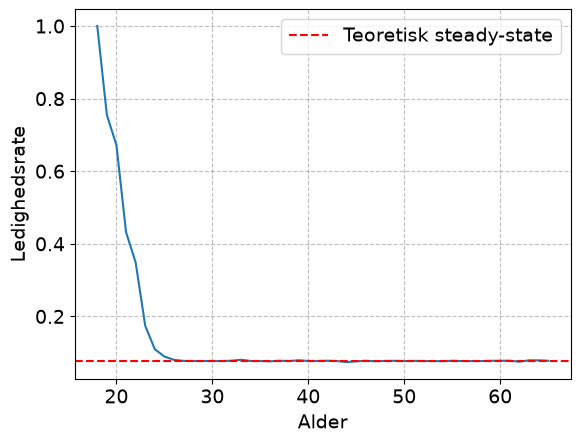

In [81]:

# Plotter ledighedsrate over tid/alder
unemp_by_age = 1 - out["employed"].mean(axis=1)  # simpel version (ignorerer uddannelse)
plt.plot(out["ages"], unemp_by_age)
plt.axhline(theoretical, color="red", linestyle="--", label="Teoretisk steady-state")
plt.xlabel("Alder")
plt.ylabel("Ledighedsrate")
plt.legend()
plt.show()


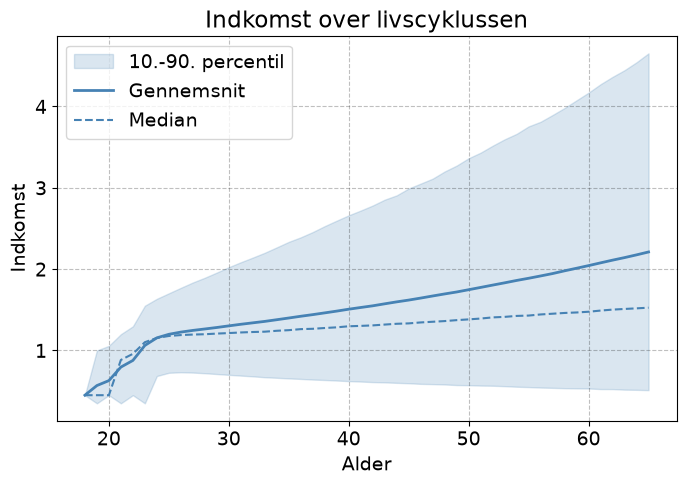

In [82]:


# OPG 2.2.2

ages = out["ages"]
income = out["income"]

mean_income = income.mean(axis=1)
p10 = np.percentile(income, 10, axis=1)
p50 = np.percentile(income, 50, axis=1)  # median
p90 = np.percentile(income, 90, axis=1)

plt.figure(figsize=(8, 5))

plt.fill_between(ages, p10, p90, alpha=0.2, color="steelblue", label="10.-90. percentil")
plt.plot(ages, mean_income, color="steelblue", linewidth=2, label="Gennemsnit")
plt.plot(ages, p50, color="steelblue", linestyle="--", label="Median")

plt.xlabel("Alder")
plt.ylabel("Indkomst")
plt.title("Indkomst over livscyklussen")
plt.legend()
plt.show()

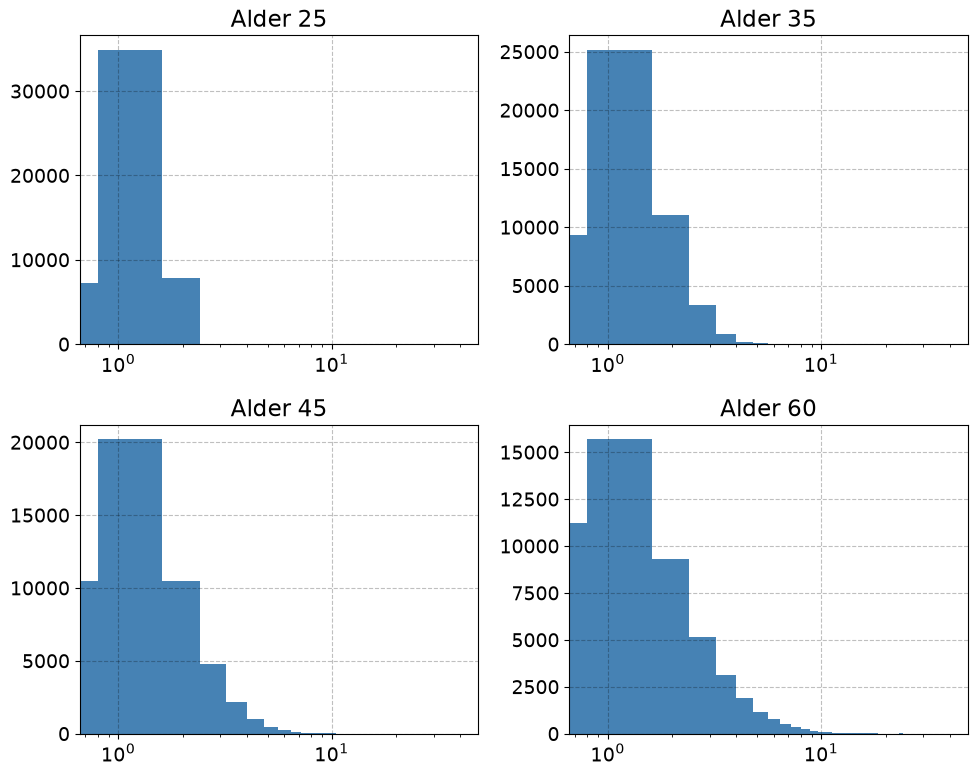

In [83]:

# OPG 2.2.3
target_ages = [25, 35, 45, 60]
target_indices = [a - 18 for a in target_ages]  # [7, 17, 27, 42]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # gør 2x2-grid til en flad liste med 4 elementer
xmax = out["income"][target_indices, :].max()

for ax, age, t in zip(axes, target_ages, target_indices):
    ax.hist(out["income"][t, :], bins=50, range=(0, xmax), color="steelblue")
    ax.set_title(f"Alder {age}")
    ax.set_xscale("log")

plt.tight_layout()
plt.show()


In [84]:
# Write the code here.

We find that ...

### Question 2.3: Compute the Gini Coefficient <a id='toc2_3_'></a>

We comepute the gini by...

Uniform: 0.33326978701903154 (forventet: 0.3333)
Lognormal (simuleret): 0.27621177510041384
Lognormal (teoretisk): 0.2763263901682369
Gini (alder 65, alle): 0.4519339217396885


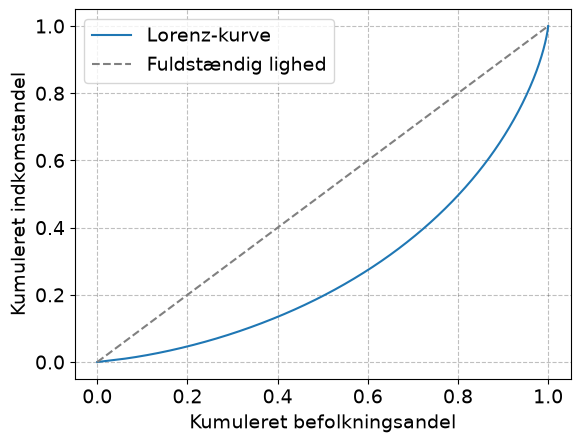

In [ ]:

# OPG 2.3 
def gini(y):
    """
    Forsøg på at indsætte en funktionsbeskrivelse:
    Beregner Gini-koefficienten for en vektor af indkomster (eller anden ikke-negativ variabel).
    
    Parameters
    ----------
    y : array-like
        Vektor af indkomster (skal være ikke-negative).
    
    Returns
    -------
    float
        Gini-koefficienten (mellem 0 og 1).
    """
    y = np.asarray(y)
    y = np.sort(y)  # sortér i stigende rækkefølge
    n = len(y)
    
    index = np.arange(1, n + 1)  # rang 1, 2, ..., n
    
    return (2 * np.sum(index * y)) / (n * np.sum(y)) - (n + 1) / n


# Test 1: Uniform fordeling på [0, 1] -> Gini bør være 1/3 (kan egentlig udelades. den bruges kun til at kalibrere)
rng = np.random.default_rng(42)
y_uniform = rng.uniform(0, 1, size=1_000_000)
print("Uniform:", gini(y_uniform), "(forventet: 0.3333)")

# Test 2: Lognormal fordeling -> Gini = 2*Phi(s/sqrt(2)) - 1 (kan også udelades. den bruges kun til at kalibrere)
from scipy.stats import norm
s = 0.5  # std af log-indkomst
y_lognormal = rng.lognormal(mean=0, sigma=s, size=1_000_000)
gini_simuleret = gini(y_lognormal)
gini_teoretisk = 2 * norm.cdf(s / np.sqrt(2)) - 1
print("Lognormal (simuleret):", gini_simuleret)
print("Lognormal (teoretisk):", gini_teoretisk)




# Gini for hele samplen, sidste periode (alder 65)
gini_hele_samplen = gini(out["income"][-1, :])
print("Gini (alder 65, alle):", gini_hele_samplen)

# Gini for hver alder separat
gini_by_age = np.array([gini(out["income"][t, :]) for t in range(len(out["ages"]))])

def lorenz_curve(y):
    y = np.sort(np.asarray(y))
    cum_y = np.cumsum(y) / np.sum(y)
    cum_y = np.insert(cum_y, 0, 0)  # start i (0,0)
    cum_pop = np.linspace(0, 1, len(cum_y))
    return cum_pop, cum_y

pop_share, income_share = lorenz_curve(out["income"][-1, :])


plt.plot(pop_share, income_share, label="Lorenz-kurve")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Fuldstændig lighed")
plt.xlabel("Kumuleret befolkningsandel")
plt.ylabel("Kumuleret indkomstandel")
plt.legend()
plt.show()




Gini (alder 65, alle): 0.4519339217396885


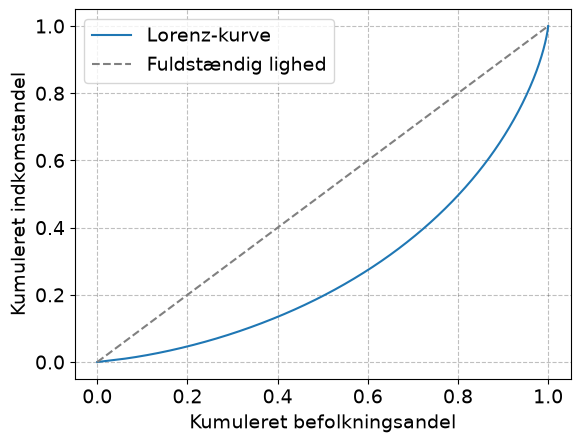

In [ ]:
# Write the code here.

We find that ...

### Question 2.4: What Drives Inequality? <a id='toc2_4_'></a>

We at inequality by...

In [ ]:
# Write the code here.

We find that ...

### Question 2.5: Extension: More Risk <a id='toc2_5_'></a>

We extent the model by...

In [ ]:
# Write the code here.

We find that ...